# Geo-FNO Elasticity Test\n
\n
Load trained elasticity model and visualize input geometry, true stress, prediction, and difference.\n

sample=68 | sigma MSE=6.337889e-01
sample=68 | sigma relRMSE=2.993126e-03 (0.299%)


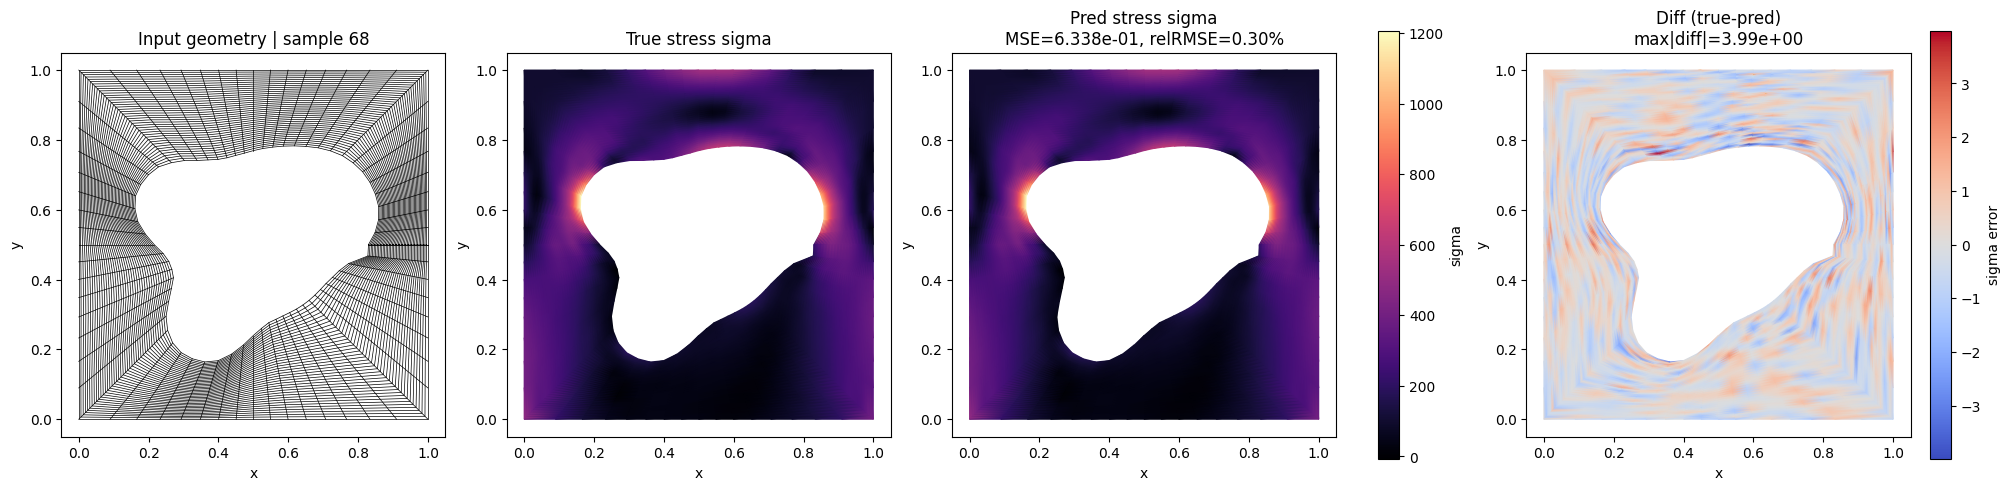

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as tri

from geo_FNO_def import FNO2d, IPHI


def relative_rmse(pred: np.ndarray, target: np.ndarray, eps: float = 1e-12) -> float:
    mse = np.mean((pred - target) ** 2)
    ref = np.mean(target ** 2)
    return float(np.sqrt(mse / max(ref, eps)))

# ----------------------------
# Config
# ----------------------------
x_path = "/scratch/mnhagen/datasets/elasticity/Random_UnitCell_Deform_X_10_interp.npy"
y_path = "/scratch/mnhagen/datasets/elasticity/Random_UnitCell_Deform_Y_10_interp.npy"
sigma_path = "/scratch/mnhagen/datasets/elasticity/Random_UnitCell_Deform_sigma_10_interp.npy"

FNO_CKPT = "/scratch/mnhagen/models/elasticity/elasticity_sigma_geofno_fno.pt"
IPHI_CKPT = "/scratch/mnhagen/models/elasticity/elasticity_sigma_geofno_iphi.pt"

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Must match training
modes = 20
width = 32
s1 = 65
s2 = 41

sample_idx = 68  # change as needed

# ----------------------------
# Load sample
# ----------------------------
X = np.load(x_path)
Y = np.load(y_path)
S = np.load(sigma_path)

assert X.shape == Y.shape == S.shape, f"Shape mismatch: {X.shape} {Y.shape} {S.shape}"
assert 0 <= sample_idx < X.shape[-1]

x2 = X[:, :, sample_idx].astype(np.float32)
y2 = Y[:, :, sample_idx].astype(np.float32)
s_gt = S[:, :, sample_idx].astype(np.float32)

nx, ny = x2.shape
pos = np.stack([x2, y2], axis=-1).reshape(-1, 2)      # (N,2)
u_in = pos.copy()                                      # geometry input
s_gt_vec = s_gt.reshape(-1, 1)                         # (N,1)

# Training used a 42-dim dummy code in elasticity
code42 = np.zeros((42,), dtype=np.float32)
code42[0] = 0.5
code42[1] = 0.5

# Triangulation from structured connectivity

def idx(i, j):
    return i * ny + j

tris = []
for i in range(nx - 1):
    for j in range(ny - 1):
        a = idx(i, j)
        b = idx(i + 1, j)
        c = idx(i, j + 1)
        d = idx(i + 1, j + 1)
        tris.append([a, b, c])
        tris.append([b, d, c])

triang = tri.Triangulation(pos[:, 0], pos[:, 1], np.asarray(tris, dtype=np.int32))

# ----------------------------
# Load trained model
# ----------------------------
L1 = float(X[:, :, 0].max() - X[:, :, 0].min())
L2 = float(Y[:, :, 0].max() - Y[:, :, 0].min())

model = FNO2d(
    modes, modes, width,
    in_channels=2, out_channels=1,
    is_mesh=False, s1=s1, s2=s2,
    L=[L1, L2],
).to(device)
model_iphi = IPHI(width=32, device=device).to(device)

model.load_state_dict(torch.load(FNO_CKPT, map_location=device), strict=False)
model_iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device), strict=False)
model.eval()
model_iphi.eval()

# ----------------------------
# Predict
# ----------------------------
pos_t = torch.from_numpy(pos).unsqueeze(0).to(device)
u_in_t = torch.from_numpy(u_in).unsqueeze(0).to(device)
code_t = torch.from_numpy(code42).unsqueeze(0).to(device)

with torch.no_grad():
    pred_t = model(u_in_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=model_iphi)

s_pred_vec = pred_t[0].cpu().numpy().astype(np.float32)

mse = float(np.mean((s_pred_vec - s_gt_vec) ** 2))
rel = relative_rmse(s_pred_vec, s_gt_vec)
print(f"sample={sample_idx} | sigma MSE={mse:.6e}")
print(f"sample={sample_idx} | sigma relRMSE={rel:.6e} ({100.0 * rel:.3f}%)")

s_true = s_gt_vec[:, 0]
s_pred = s_pred_vec[:, 0]
s_diff = s_true - s_pred

common_min = float(min(s_true.min(), s_pred.min()))
common_max = float(max(s_true.max(), s_pred.max()))
diff_abs = float(np.max(np.abs(s_diff)))

# ----------------------------
# Plot input / GT / pred / diff
# ----------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

axes[0].set_title(f"Input geometry | sample {sample_idx}")
for i in range(nx):
    axes[0].plot(x2[i, :], y2[i, :], color="black", lw=0.5)
for j in range(ny):
    axes[0].plot(x2[:, j], y2[:, j], color="black", lw=0.5)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1 = axes[1].tripcolor(triang, s_true, shading="gouraud", cmap="magma", vmin=common_min, vmax=common_max)
axes[1].set_title("True stress sigma")
axes[1].set_aspect("equal")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

im2 = axes[2].tripcolor(triang, s_pred, shading="gouraud", cmap="magma", vmin=common_min, vmax=common_max)
axes[2].set_title(f"Pred stress sigma\nMSE={mse:.3e}, relRMSE={100.0 * rel:.2f}%")
axes[2].set_aspect("equal")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

im3 = axes[3].tripcolor(triang, s_diff, shading="gouraud", cmap="coolwarm", vmin=-diff_abs, vmax=diff_abs)
axes[3].set_title(f"Diff (true-pred)\nmax|diff|={diff_abs:.2e}")
axes[3].set_aspect("equal")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")

fig.colorbar(im2, ax=axes[1:3], shrink=0.9, label="sigma")
fig.colorbar(im3, ax=axes[3], shrink=0.9, label="sigma error")
plt.show()
